<a href="https://colab.research.google.com/github/imannolM/2250-IA-para-Desarrolladores-Desarrollando-Coodigos-con-ChatGPT-Grok-Claude-y-Gemini/blob/main/CursoAgentesIAyRAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conexion con LLMs

In [55]:
!pip install -q langchain langchain-google-genai google-generativeai
!pip install -q langchain-cohere
!pip install -q langchain-groq
!pip install -q -U langchain

In [56]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
COHERE_API_KEY = userdata.get('COHERE_API_KEY')

In [57]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain_cohere import ChatCohere

llm_gemini = ChatGoogleGenerativeAI(
    model = 'gemini-2.5-flash',
    temperature = 0,
    google_api_key = GEMINI_API_KEY
)

llm_groq = ChatGroq(
    model='meta-llama/llama-4-scout-17b-16e-instruct',
    groq_api_key=GROQ_API_KEY,
    temperature = 0
)

In [58]:
respuesta = llm_groq.invoke('Que es el RAG en Inteligencia Artificial?')

In [59]:
respuesta.content

'El RAG (Retrieval-Augmented Generator) es un enfoque de inteligencia artificial (IA) que combina dos técnicas fundamentales en el procesamiento del lenguaje natural (NLP) y la generación de texto: la recuperación de información (retrieval) y la generación de texto (generation).\n\n**Componentes del RAG:**\n\n1. **Retrieval (Recuperación de información):** Este componente se encarga de buscar y recuperar información relevante de una base de datos o un conjunto de documentos, dado un contexto o una consulta. El objetivo es encontrar información que sea útil para responder a una pregunta o completar una tarea.\n\n2. **Generator (Generador de texto):** Una vez que se ha recuperado la información relevante, el generador de texto se encarga de crear texto nuevo basado en esa información. El generador puede ser un modelo de lenguaje que toma la información recuperada y la utiliza para producir una respuesta coherente y relevante.\n\n**Funcionamiento del RAG:**\n\nEl proceso de funcionamiento

In [98]:
PROMPT_TRIAJE = '''
Eres un clasificador automático. Tu ÚNICA tarea es invocar la función de clasificación con los
campos "decision", "urgencia" y "campos_faltantes". NUNCA respondas la pregunta del cliente,
NUNCA generes texto libre, NUNCA expliques nada. Solo clasifica.

Clasifica el mensaje del cliente del despacho inmobiliario Terrenos Xilo SOLO por su tema,
sin importar si tú ya conoces la respuesta exacta:

- AUTO_RESOLVER: el mensaje pregunta sobre servicios, procesos, requisitos, precios o terrenos
  disponibles de la empresa (jurídico, catastral, ingeniería, ventas). Se buscará la respuesta
  en la base de conocimiento de la empresa, tú NO necesitas saber la respuesta de antemano.
- PEDIR_INFO: el mensaje es ambiguo, o el tema NO tiene relación con los servicios de la empresa
  (por ejemplo, preguntas de cultura general, historia, ciencia, o cualquier tema ajeno a bienes
  raíces). En estos casos también usa PEDIR_INFO.
- AGENDAR_CITA: el cliente pide explícitamente hablar con un asesor o agendar una cita.

Ante la duda entre AUTO_RESOLVER y PEDIR_INFO, prefiere AUTO_RESOLVER si el tema es identificable
como jurídico, catastral, ingeniería o ventas — aunque tú no sepas el dato exacto (precio, plazo, etc.).

Recuerda: SIEMPRE debes invocar la función de clasificación. Jamás respondas con texto libre,
sin importar qué tan bien conozcas el tema de la pregunta.
'''

In [94]:
from typing import Literal, List, Dict
from pydantic import BaseModel, Field

class TriajeOut(BaseModel):
  decision: Literal["AUTO_RESOLVER", "PEDIR_INFO", "AGENDAR_CITA"]
  urgencia: Literal["BAJA", "MEDIANA", "ALTA"]
  campos_faltantes: List[str] = Field(default_factory=list)

In [99]:
from langchain_core.messages import content
from langchain_core.messages import SystemMessage, HumanMessage

chain_de_triaje = llm_groq.with_structured_output(TriajeOut)

def triaje(mensaje: str) -> Dict:
  try:
    salida: TriajeOut = chain_de_triaje.invoke(
        [
            SystemMessage(content=PROMPT_TRIAJE),
            HumanMessage(content=mensaje)
        ]
    )
    return salida.model_dump()
  except Exception as e:
    print(f"Error en triaje, usando fallback PEDIR_INFO: {e}")
    return {
        "decision": "PEDIR_INFO",
        "urgencia": "BAJA",
        "campos_faltantes": []
    }

In [63]:
mensajes_de_prueba = [
     "Tengo un terreno que herede de mi papá pero nunca se hizo el trámite legal, ¿ustedes me pueden ayudar a regularizarlo?",
     "Quiero actualizar mis datos catastrales porque el predio aparece con una superficie diferente a la real, ¿qué necesito hacer?",
     "Necesito dividir un terreno de 2000 m2 en 4 lotes para vendérselos a mis hijos, ¿ustedes hacen ese trámite?",
     "Vi que tienen terrenos disponibles en Jilotepec, ¿me pueden compartir precios y ubicaciones?",
     "Quiero comprar un terreno pero primero necesito saber si está bien deslindado y si tiene problemas legales"
]

for pregunta in mensajes_de_prueba:
  r = triaje(pregunta)
  print(f'{pregunta} -> {r}')

Tengo un terreno que herede de mi papá pero nunca se hizo el trámite legal, ¿ustedes me pueden ayudar a regularizarlo? -> {'decision': 'PEDIR_INFO', 'urgencia': 'MEDIANA', 'campos_faltantes': ['nombre del terreno', 'documentación del terreno']}
Quiero actualizar mis datos catastrales porque el predio aparece con una superficie diferente a la real, ¿qué necesito hacer? -> {'decision': 'PEDIR_INFO', 'urgencia': 'MEDIANA', 'campos_faltantes': ['ubicación del predio', 'superficie real del predio']}
Necesito dividir un terreno de 2000 m2 en 4 lotes para vendérselos a mis hijos, ¿ustedes hacen ese trámite? -> {'decision': 'PEDIR_INFO', 'urgencia': 'BAJA', 'campos_faltantes': []}
Vi que tienen terrenos disponibles en Jilotepec, ¿me pueden compartir precios y ubicaciones? -> {'decision': 'PEDIR_INFO', 'urgencia': 'BAJA', 'campos_faltantes': []}
Quiero comprar un terreno pero primero necesito saber si está bien deslindado y si tiene problemas legales -> {'decision': 'PEDIR_INFO', 'urgencia': 'M

# RAG

In [64]:
!pip install -q langchain_community faiss-cpu langchain-text-splitters pymupdf

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [65]:
!pip install -q requests==2.32.4

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-community 0.4.2 requires requests<3.0.0,>=2.32.5, but you have requests 2.32.4 which is incompatible.


In [66]:
from pathlib import Path
from langchain_community.document_loaders import PyMuPDFLoader

docs = []

for documento in Path("/content/").glob("*.pdf"):
  try:
    loader = PyMuPDFLoader(str(documento))
    docs.extend(loader.load())
    print(f"Archivo cargado: {documento.name}")
  except Exception as e:
    print(f"Error cargando archivo: {documento.name}: {e}")

print(f'Total de documentos cargados: {len(docs)}')


Archivo cargado: 01_Politicas_y_Servicios_Generales.pdf
Archivo cargado: 02_Proceso_Compra_Venta.pdf
Archivo cargado: 03_Procesos_Departamento_Ingenieria.pdf
Total de documentos cargados: 3


In [67]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size = 300, chunk_overlap = 30)
chunks = splitter.split_documents(docs)

In [68]:
for chunk in chunks:
  print(chunk)
  print('_________________________')

page_content='Terrenos Xilo · Documento interno de referencia · Página 1
TERRENOS XILO
Despacho Inmobiliario • Jilotepec, Estado de México
POLÍTICAS Y SERVICIOS GENERALES
1. Quiénes somos
Terrenos Xilo es un despacho inmobiliario con sede en Jilotepec, Estado de México, especializado en la' metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-07-05T06:03:00+00:00', 'source': '/content/01_Politicas_y_Servicios_Generales.pdf', 'file_path': '/content/01_Politicas_y_Servicios_Generales.pdf', 'total_pages': 1, 'format': 'PDF 1.4', 'title': '(anonymous)', 'author': '(anonymous)', 'subject': '(unspecified)', 'keywords': '', 'moddate': '2026-07-05T06:03:00+00:00', 'trapped': '', 'modDate': "D:20260705060300+00'00'", 'creationDate': "D:20260705060300+00'00'", 'page': 0}
_________________________
page_content='regularización, gestión técnica y comercialización de terrenos. Operamos a través de cuatro departamentos
especializados que trab

In [69]:
from langchain_cohere import CohereEmbeddings

modelo_embeddings = CohereEmbeddings(
    model="embed-multilingual-v3.0",
    cohere_api_key = COHERE_API_KEY
)

In [70]:
from re import search
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(chunks, modelo_embeddings)

retriever = vectorstore.as_retriever(
    search_type = 'similarity_score_threshold',
    search_kwargs = {'score_threshold': 0.3, 'k': 4}
)

In [71]:
!pip install -q -U langchain-classic
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

prompt_rag = ChatPromptTemplate(
    [
        ('system',
         """
         Eres el espacialista en los procesos de servicios y ventas del despacho inmobiliario Terrenos Xilo.
         Responde simpre utilizando los conocimientos de las bases de datos pasadas a ti.
         Si no hay informacion sobre la pregunta del ciente en el contexto, responde solo 'No tengo información sobre eso'.
         """),
        ('human','Contexto: {context}.\nPregunta del cliente: {input}')
    ]
)

document_chain = create_stuff_documents_chain(llm_groq, prompt_rag)

In [72]:
def busqueda_de_respuestas_RAG(pregunta) -> Dict:
  documentos_relacionados = retriever.invoke(pregunta)

  if not documentos_relacionados:
    return{
        'respuesta': 'No tengo informacion sobre eso.',
        'citaciones': [],
        'documentos_encontrados': False
    }

  answer = document_chain.invoke({
      'input': pregunta,
      'context': documentos_relacionados
  })

  if answer.rstrip('.!?') == 'No tengo informacion sobre eso.':
    return{
        'respuesta': 'No tengo informacion sobre eso',
        'citaciones': [],
        'documentos_encontrados': False
    }

  return {
      'respuesta': answer,
      'citaciones': documentos_relacionados,
      'documentos_encontrados': True
    }

In [73]:
r = busqueda_de_respuestas_RAG('Quiero actualizar mis datos catastrales porque el predio aparece con una superficie diferente a la real, ¿qué necesito hacer?')
print(r)

{'respuesta': 'Para actualizar tus datos catastrales porque el predio aparece con una superficie diferente a la real, te recomiendo seguir los siguientes pasos:\n\n1. **Proporciona documentación básica**: Necesitamos que nos proporciones documentación básica del predio, como posesión, escritura previa o certificado catastral, si existen.\n\n2. **Evaluación documental**: Nuestro equipo revisará la documentación proporcionada para verificar si el terreno cuenta con escritura, posesión regularizada o certificado catastral vigente.\n\n3. **Medición y cálculo de superficie real**: Realizaremos una medición para determinar la superficie real del predio. Esto te permitirá obtener un reporte con la superficie real y útil para comparar contra los datos catastrales existentes.\n\n4. **Deslinde y resolución de conflictos (si aplica)**: Si hay conflictos de límites con propietarios vecinos, nuestro equipo puede realizar mediciones oficiales para resolverlos.\n\n5. **Recomendación de regularización

In [74]:
len(r['citaciones'])

4

In [75]:
mensajes_de_prueba = [
     "Tengo un terreno que herede de mi papá pero nunca se hizo el trámite legal, ¿ustedes me pueden ayudar a regularizarlo?",
     "Quiero actualizar mis datos catastrales porque el predio aparece con una superficie diferente a la real, ¿qué necesito hacer?",
     "Necesito dividir un terreno de 2000 m2 en 4 lotes para vendérselos a mis hijos, ¿ustedes hacen ese trámite?",
     "Vi que tienen terrenos disponibles en Jilotepec, ¿me pueden compartir precios y ubicaciones?",
     "Quien fue Madame Curie?"
]

In [76]:
for pregunta in mensajes_de_prueba:
  respuesta_RAG = busqueda_de_respuestas_RAG(pregunta)
  print(f'PREGUNTA: {pregunta}')
  print(f'RESPUESTA: {respuesta_RAG["respuesta"]}')
  if respuesta_RAG["documentos_encontrados"]:
    for i, citacion in enumerate(respuesta_RAG["citaciones"]):
      print(f'    -CITACION {i+1}:')
      print(f'      Ruta del documento: {citacion.metadata["file_path"]}')
      print(f'      Contenido: {citacion.page_content.replace('\n','')}')
  print('_____________________________________________________________________________')


PREGUNTA: Tengo un terreno que herede de mi papá pero nunca se hizo el trámite legal, ¿ustedes me pueden ayudar a regularizarlo?
RESPUESTA: Sí, podemos ayudarte a regularizar el terreno heredado. Nuestro departamento Jurídico se encarga de la regularización legal de terrenos, incluyendo herencias y escrituración. 

Para iniciar el proceso, necesitaríamos que nos proporcionaras la documentación básica del predio, como la posesión o cualquier otro documento que acredite la propiedad anterior (en este caso, la herencia de tu papá). 

Una vez que tengamos la documentación, podremos evaluar el caso y recomendarte el proceso de regularización adecuado. También te informaremos sobre los tiempos de respuesta estimados y los pasos necesarios para completar el trámite.

¿Quieres proporcionar la documentación que tengas para empezar?
    -CITACION 1:
      Ruta del documento: /content/02_Proceso_Compra_Venta.pdf
      Contenido: • Evaluación documental: se revisa si el terreno cuenta con escritur

PREGUNTA: Vi que tienen terrenos disponibles en Jilotepec, ¿me pueden compartir precios y ubicaciones?
RESPUESTA: No tengo información sobre eso.
    -CITACION 1:
      Ruta del documento: /content/01_Politicas_y_Servicios_Generales.pdf
      Contenido: Terrenos Xilo · Documento interno de referencia · Página 1TERRENOS XILODespacho Inmobiliario • Jilotepec, Estado de MéxicoPOLÍTICAS Y SERVICIOS GENERALES1. Quiénes somosTerrenos Xilo es un despacho inmobiliario con sede en Jilotepec, Estado de México, especializado en la
    -CITACION 2:
      Ruta del documento: /content/01_Politicas_y_Servicios_Generales.pdf
      Contenido: propietario del inmueble.• La confidencialidad de la información y documentación del cliente se mantiene en todo momento.4. Alcance de los serviciosTodos los servicios están enfocados en terrenos ubicados principalmente en la región de Jilotepec y zonas
    -CITACION 3:
      Ruta del documento: /content/02_Proceso_Compra_Venta.pdf
      Contenido: Terrenos Xilo ·

# Agente con LangGraph

In [77]:
!pip install -q langgraph

In [78]:
from typing import TypedDict, Optional

class  AgentState(TypedDict, total = False):
  pregunta: str
  triaje: dict
  respuesta: Optional[str]
  citaciones: Optional[list]
  rag_exito: bool
  accion_final: str

In [79]:
def nodo_triaje(state: AgentState) -> AgentState:
  print("Ejecutando nodo triaje...")
  return {"triaje": triaje(state["pregunta"])}

In [80]:
def nodo_auto_resolver(state: AgentState) -> AgentState:
  print("Ejecutando nodo auto_resolver...")
  respuesta_RAG = busqueda_de_respuestas_RAG(state["pregunta"])

  update: AgentState = {
      "respuesta": respuesta_RAG["respuesta"],
      "citaciones": respuesta_RAG["citaciones"],
      "rag_exito": respuesta_RAG["documentos_encontrados"]
  }

  if respuesta_RAG["documentos_encontrados"]:
    update["accion_final"] = "AUTO_RESOLVER"

  return update


In [81]:
def nodo_pedir_info(state: AgentState) -> AgentState:
  print("Ejecutando nodo pedir_info...")
  return {
      "respuesta": "Necesito mas informacion sobre tu solicitud.",
      "citaciones": [],
      "accion_final": "PEDIR_INFO"
  }

In [82]:
def nodo_agendar_cita(state: AgentState) -> AgentState:
  print("Ejecutando nodo agendar_cita...")

  tri = state["triaje"]

  return{
      "respuesta": f"Agendar cita con urgencia {tri['urgencia']}. Solicitud: {state['pregunta']}.",
      "citaciones": [],
      "accion_final": "AGENDAR_CITA"
  }

In [83]:
def arista_decision_triaje(state: AgentState) -> AgentState:
  print("Decidiendo el flujo despues del nodo 'triaje'...")
  tri = state["triaje"]

  if tri["decision"] == "AUTO_RESOLVER":
    return "rag"
  elif tri["decision"] == "PEDIR_INFO":
    return "info"
  else:
    return "cita"

In [101]:
def arista_decision_rag(state: AgentState) -> str:
  print("Decidiendo el flujo despues del nodo 'auto_resolver'...")
  if state["rag_exito"]:
    print("RAG exitoso, finalizando el flujo.")
    return "ok"

  KEYWORDS_AGENDAR_CITA = ["aprobacion", "aprobar", "excepcion", "liberacion", "autorizacion",
                         "autorizar", "abrir ticket", "acceso especial"]

  if any(keyword in state["pregunta"].lower() for keyword in KEYWORDS_AGENDAR_CITA):
    print("RAG ha fallado, pero hay palabras relacionadas con agendar cita.")
    return "cita"

  print("RAG ha fallado, pedire mas informaciones al usuario.")
  return "info"

In [85]:
from langgraph.graph import START, END, StateGraph

workflow = StateGraph(AgentState)

workflow.add_node("triaje", nodo_triaje)
workflow.add_node("auto_resolver", nodo_auto_resolver)
workflow.add_node("pedir_info", nodo_pedir_info)
workflow.add_node("agendar_cita", nodo_agendar_cita)

workflow.add_edge(START, "triaje")
workflow.add_conditional_edges("triaje", arista_decision_triaje, {
    "rag": "auto_resolver",
    "info": "pedir_info",
    "cita": "agendar_cita"
})

workflow.add_conditional_edges("auto_resolver", arista_decision_rag, {
    "info": "pedir_info",
    "cita": "agendar_cita",
    "ok": END
})

workflow.add_edge("pedir_info", END)
workflow.add_edge("agendar_cita", END)

grafo = workflow.compile()


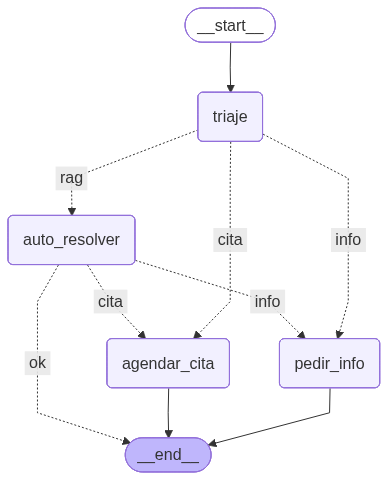

In [86]:
from IPython.display import display, Image

graph_bytes = grafo.get_graph().draw_mermaid_png()
display(Image(graph_bytes))

In [87]:
PREGUNTA = "Puedo vender mi terreno con ustedes?"

respuesta = grafo.invoke({"pregunta": PREGUNTA})
print("")
print(f'PREGUNTA: {PREGUNTA}')
print(f'DECISION DE TRIAJE: {respuesta['triaje']['decision']} | URGENCIA: {respuesta["triaje"]["urgencia"]} | ACCION FINAL: {respuesta['accion_final']}')
print(f'RESPUESTA: {respuesta["respuesta"]}')
if respuesta["citaciones"]:
  for i, citacion in enumerate(respuesta["citaciones"]):
    print(f'    -CITACION {i+1}:')
    print(f'      Ruta del documento: {citacion.metadata["file_path"]}')
    print(f'      Contenido: {citacion.page_content.replace('\n','')}')

Ejecutando nodo triaje...
Decidiendo el flujo despues del nodo 'triaje'...
Ejecutando nodo auto_resolver...
Decidiendo el flujo despues del nodo 'auto_resolver'...
RAG exitoso, finalizando el flujo.

PREGUNTA: Puedo vender mi terreno con ustedes?
DECISION DE TRIAJE: AUTO_RESOLVER | URGENCIA: BAJA | ACCION FINAL: AUTO_RESOLVER
RESPUESTA: Sí, puedes vender tu terreno con nuestra ayuda. En Terrenos Xilo nos encargamos de conectar a vendedores y compradores, y brindamos acompañamiento durante todo el proceso. 

Para iniciar, te ofrecemos una valoración inicial gratuita de tu terreno. Una vez que tengamos la información de tu propiedad, podremos integrarla a nuestros canales de promoción y empezar a buscar posibles compradores. 

Durante el proceso de negociación, te brindaremos apoyo para que puedas tener una experiencia segura y exitosa. 

Finalmente, recomendamos formalizar la venta ante notario o mediante los mecanismos legales correspondientes para garantizar la seguridad de la transac

In [102]:
mensajes_de_prueba = [
     "Tengo un terreno que herede de mi papá pero nunca se hizo el trámite legal, ¿ustedes me pueden ayudar a regularizarlo?",
     "Puedo vender mi terreno con ustedes?",
     "Necesito dividir un terreno de 2000 m2 en 4 lotes para vendérselos a mis hijos, ¿ustedes hacen ese trámite?",
     "Vi que tienen terrenos disponibles en Jilotepec, ¿me pueden compartir precios y ubicaciones?",
     "Quien fue Madame Curie?"
]

In [103]:
for prueba in mensajes_de_prueba:
  respuesta = grafo.invoke({"pregunta": prueba})
  print("")
  print(f'PREGUNTA: {prueba}')
  print(f'DECISION DE TRIAJE: {respuesta['triaje']['decision']} | URGENCIA: {respuesta["triaje"]["urgencia"]} | ACCION FINAL: {respuesta['accion_final']}')
  print(f'RESPUESTA: {respuesta["respuesta"]}')
  if respuesta["citaciones"]:
    for i, citacion in enumerate(respuesta["citaciones"]):
      print(f'    -CITACION {i+1}:')
      print(f'      Ruta del documento: {citacion.metadata["file_path"]}')
      print(f'      Contenido: {citacion.page_content.replace('\n','')}')
  print("____________________________________________")

Ejecutando nodo triaje...
Decidiendo el flujo despues del nodo 'triaje'...
Ejecutando nodo auto_resolver...
Decidiendo el flujo despues del nodo 'auto_resolver'...
RAG exitoso, finalizando el flujo.

PREGUNTA: Tengo un terreno que herede de mi papá pero nunca se hizo el trámite legal, ¿ustedes me pueden ayudar a regularizarlo?
DECISION DE TRIAJE: AUTO_RESOLVER | URGENCIA: MEDIANA | ACCION FINAL: AUTO_RESOLVER
RESPUESTA: Sí, podemos ayudarte a regularizar el terreno heredado. Nuestro departamento Jurídico se encarga de la regularización legal de terrenos, incluyendo herencias y escrituración. 

Para iniciar el proceso, necesitaríamos que nos proporcionaras la documentación básica del predio, como la posesión o cualquier otro documento que acredite la propiedad anterior (en este caso, la herencia de tu papá). 

Una vez que tengamos la documentación, podremos evaluar el caso y recomendarte el proceso de regularización adecuado. También te informaremos sobre los tiempos de respuesta estima

In [100]:
for pregunta in mensajes_de_prueba:
  print(pregunta, "->", triaje(pregunta))

Tengo un terreno que herede de mi papá pero nunca se hizo el trámite legal, ¿ustedes me pueden ayudar a regularizarlo? -> {'decision': 'AUTO_RESOLVER', 'urgencia': 'MEDIANA', 'campos_faltantes': []}
Puedo vender mi terreno con ustedes? -> {'decision': 'AUTO_RESOLVER', 'urgencia': 'BAJA', 'campos_faltantes': []}
Necesito dividir un terreno de 2000 m2 en 4 lotes para vendérselos a mis hijos, ¿ustedes hacen ese trámite? -> {'decision': 'AUTO_RESOLVER', 'urgencia': 'BAJA', 'campos_faltantes': []}
Vi que tienen terrenos disponibles en Jilotepec, ¿me pueden compartir precios y ubicaciones? -> {'decision': 'AUTO_RESOLVER', 'urgencia': 'BAJA', 'campos_faltantes': []}
Quien fue Madame Curie? -> {'decision': 'PEDIR_INFO', 'urgencia': 'BAJA', 'campos_faltantes': []}
